# Task 1: Data Understanding and Visualization

In [20]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and ML/Week 5/FruitinAmazon.zip"
extract_path = "/content/Fruit"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done.")

Extraction done.


In [8]:
print(os.listdir(extract_path))
train_dir = "/content/Fruit/FruitinAmazon/train"

['FruitinAmazon']


In [9]:
class_names = os.listdir(train_dir)
print("Classes:", class_names)
print("Total Classes:", len(class_names))

Classes: ['pupunha', 'cupuacu', 'acai', 'graviola', 'tucuma', 'guarana']
Total Classes: 6


## Select random image per class

In [10]:
import random

sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)

    if len(images) == 0:
        continue

    img_name = random.choice(images)
    img_path = os.path.join(class_path, img_name)

    sample_images.append((class_name, img_path))

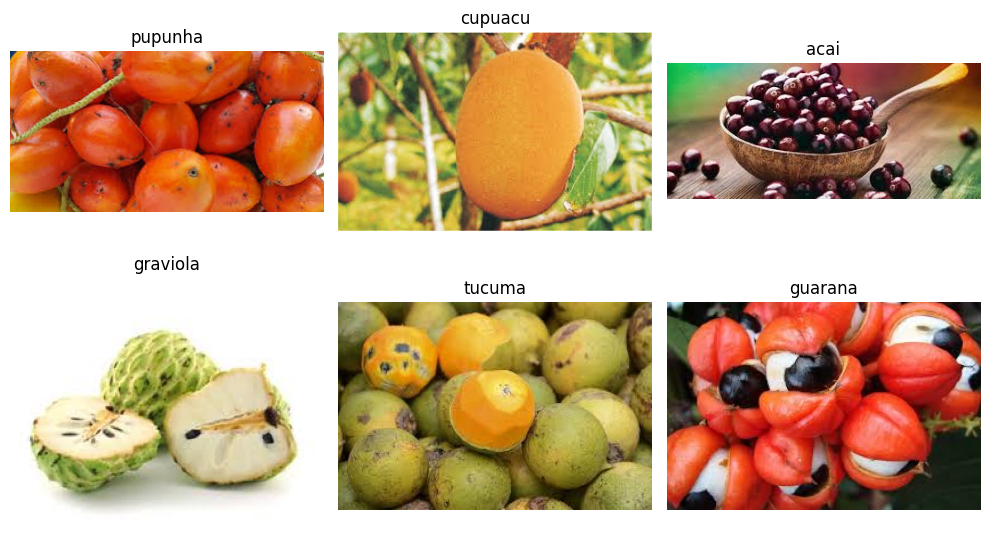

In [17]:
# display images
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(10, 6))
rows = 2
cols = 3
for i, (label, img_path) in enumerate(sample_images[:6]):
    img = Image.open(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

Multiple fruit classes are stored in different folders. Most pictures contain a bunch of fruits while cupuacu fruit picture is of a single fruit.

## Check for Corrupted Images

In [14]:
from PIL import Image
corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            print(f"Removed corrupted image: {img_path}")
            corrupted_images.append(img_path)
            os.remove(img_path)

In [19]:
if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


# Task 2: Loading and Preprocessing Image Data in keras:

In [76]:
import tensorflow as tf
# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
# Normalize
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [77]:
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dropout(0.3),
layers.Dense(128, activation='relu'),
layers.Dense(num_classes, activation='softmax')

<Dense name=dense_35, built=False>

# Task 3: CNN Model

In [78]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile Model




In [79]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [80]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
earlystop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.1852 - loss: 1.9398

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 382ms/step - accuracy: 0.1806 - loss: 2.0325 - val_accuracy: 0.0000e+00 - val_loss: 1.9526
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.1834 - loss: 1.8256

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step - accuracy: 0.2222 - loss: 1.7739 - val_accuracy: 0.7222 - val_loss: 1.4375
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.3796 - loss: 1.6586

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 307ms/step - accuracy: 0.3889 - loss: 1.6017 - val_accuracy: 0.7778 - val_loss: 1.1513
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.3536 - loss: 1.4755

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step - accuracy: 0.3889 - loss: 1.4290 - val_accuracy: 0.7778 - val_loss: 1.1004
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.4149 - loss: 1.4291

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 335ms/step - accuracy: 0.9167 - loss: 0.1869 - val_accuracy: 0.8333 - val_loss: 0.3044
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.9444 - loss: 0.1837 - val_accuracy: 0.8889 - val_loss: 0.4237
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 0.9444 - loss: 0.1847 - val_accuracy: 0.8889 - val_loss: 0.4656
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 276ms/step - accuracy: 0.9583 - loss: 0.1222 - val_accuracy: 0.8889 - val_loss: 0.3527
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step - accuracy: 0.9722 - loss: 0.1140 - val_accuracy: 0.8889 - val_loss: 0.3176
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9404 - loss: 0.1768

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step - accuracy: 0.9306 - loss: 0.1748 - val_accuracy: 0.8889 - val_loss: 0.2618
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 0.9861 - loss: 0.0838 - val_accuracy: 0.8333 - val_loss: 0.3614
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9294 - loss: 0.1375

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step - accuracy: 0.9444 - loss: 0.1178 - val_accuracy: 0.8889 - val_loss: 0.2348
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9450 - loss: 0.1622

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - accuracy: 0.9444 - loss: 0.1579 - val_accuracy: 0.9444 - val_loss: 0.2303
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9803 - loss: 0.1136

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.9722 - loss: 0.1196 - val_accuracy: 0.9444 - val_loss: 0.1205
Epoch 28/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 461ms/step - accuracy: 0.9722 - loss: 0.1280 - val_accuracy: 0.8889 - val_loss: 0.2556
Epoch 29/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 414ms/step - accuracy: 1.0000 - loss: 0.0699 - val_accuracy: 0.8889 - val_loss: 0.5184
Epoch 30/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 276ms/step - accuracy: 0.9444 - loss: 0.1457 - val_accuracy: 0.8889 - val_loss: 0.2474
Epoch 31/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step - accuracy: 0.9583 - loss: 0.0956 - val_accuracy: 1.0000 - val_loss: 0.1304
Epoch 32/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - accuracy: 0.9722 - loss: 0.1208 - val_accuracy: 0.8889 - val_loss: 0.1523
Epoch 33/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 266ms/step - accuracy: 1.0000 - loss: 0.0348 - val_accuracy: 0.9444 - val_loss: 0.2186
Epoch 34/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step - accuracy: 1.0000 - loss: 0.0256 - val_accuracy: 0.8889 - val_lo

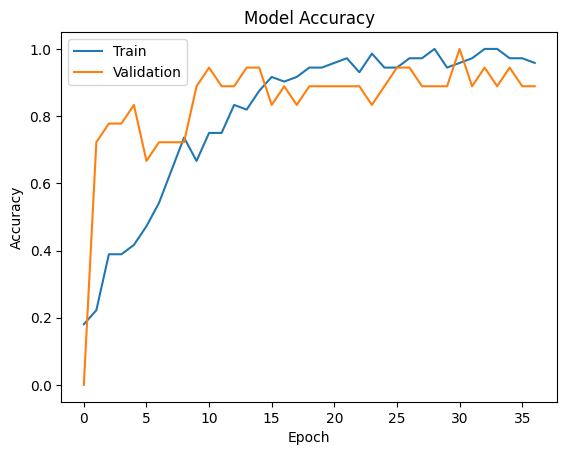

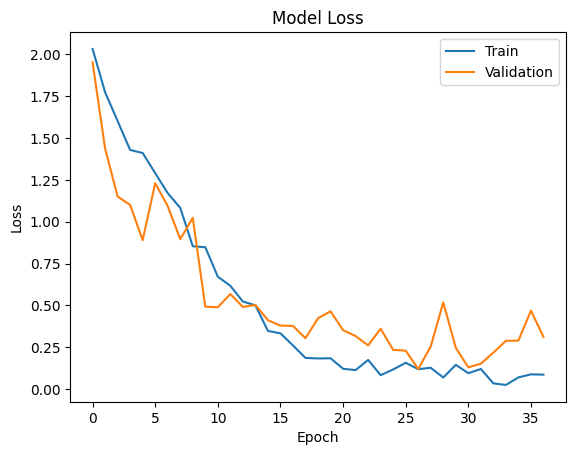

In [81]:
# Plot Graphs
import matplotlib.pyplot as plt
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Task 5: Evaluate Model

In [82]:
test_dir = "/content/Fruit/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)
print("Test Loss:", loss)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8000 - loss: 0.6212
Test Accuracy: 0.800000011920929
Test Loss: 0.6212061643600464


# Task 6: Save & Load Model

In [83]:
# Save model
model.save("final_model.h5")
# Load model
from tensorflow.keras.models import load_model
loaded_model = load_model("final_model.h5")
# Re-evaluate
loss, acc = loaded_model.evaluate(test_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.8000 - loss: 0.6212
Loaded Model Accuracy: 0.800000011920929


# Task 7: Predictions and Classification Report

In [84]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
              precision    recall  f1-score   support

     pupunha       0.80      0.80      0.80         5
     cupuacu       0.67      0.80      0.73         5
        acai       0.71      1.00      0.83         5
    graviola       1.00      0.80      0.89         5
      tucuma       0.83      1.00      0.91         5
     guarana       1.00      0.40      0.57         5

    accuracy                           0.80        30
   macro avg       0.84      0.80      0.79        30
weighted avg       0.84      0.80      0.79        30

